In [1]:
import numpy
from galpy.orbit import Orbit

ts = numpy.linspace(0.0, 100.0, 1001)
o = Orbit([0.75, 0.05, 0.15, 0.7, 0.025, 0.9])

from galpy.potential import MWPotential2014
from galpy.potential import (
    PerfectEllipsoidPotential,
    NFWPotential,
    TriaxialNFWPotential,
)

tri_pot = TriaxialNFWPotential(amp=1.0, a=1.0, b=0.8, c=0.6)

ppot = PerfectEllipsoidPotential()
sphere_pot = NFWPotential()

from galpy.actionAngle import estimateDeltaStaeckel, estimateAlphaBetaGammaStaeckel
from galpy.actionAngle import actionAngleStaeckel, actionAngleTriaxialStaeckel
from galpy.actionAngle import (
    actionAngleStaeckelSingle,
    actionAngleTriaxialStaeckelSingle,
)
# aAS= actionAngleStaeckel(pot=MWPotential2014,delta=0.4,c=False)

In [2]:
o.integrate(ts, sphere_pot)
o.jr(), o.jp(), o.jz()

# aAS.JR(), aAS.Jphi(), aAS.Jz()

(0.08088463050474998, 0.11249999999999999, 0.04224273003924933)

In [3]:
aATS_SPHERE = actionAngleTriaxialStaeckelSingle(
    o.R(),
    o.vR(),
    o.vT(),
    o.z(),
    o.vz(),
    o.phi(),
    pot=sphere_pot,
    alpha=-1,
    beta=-0.9999,
    gamma=-0.9998,
)
aATS_SPHERE.JR(), aATS_SPHERE.Jphi(), aATS_SPHERE.Jz()

(0.08441948746501635, 0.0267309457962457, 0.10898739712845301)

In [4]:
aATS = actionAngleTriaxialStaeckelSingle(
    o.R(),
    o.vR(),
    o.vT(),
    o.z(),
    o.vz(),
    o.phi(),
    pot=tri_pot,
    alpha=-1,
    beta=-0.64,
    gamma=-0.36,
)
aATS.JR(), aATS.Jphi(), aATS.Jz()

(0.03401969963527735, 0.01577186729228423, 0.13334132060091844)

In [5]:
aATS.JR(), aATS.Jphi(), aATS.Jz()

(0.03401969963527759, 0.01577186729228423, 0.13334132060091844)

In [7]:
aATS._beta

-0.64

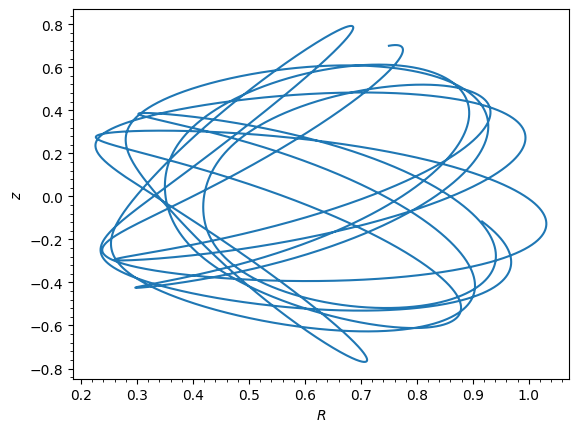

In [7]:
ts = numpy.linspace(0.0, 100.0, 10001)

o.integrate(ts, tri_pot)
o.plot()

In [166]:
def cartesian_to_ellipsoidal(x, y, z, alpha, beta, gamma):
    # using the code from galaxiesbook.org
    x = numpy.atleast_1d(x)
    y = numpy.atleast_1d(y)
    z = numpy.atleast_1d(z)
    N = len(x)
    out = numpy.empty((N, 3))
    for ii, (tx, ty, tz) in enumerate(zip(x, y, z)):
        these_coords = numpy.polynomial.polynomial.Polynomial(
            (
                beta * gamma * tx**2.0
                + alpha * gamma * ty**2.0
                + alpha * beta * tz**2.0
                - alpha * beta * gamma,
                (beta + gamma) * tx**2.0
                + (alpha + gamma) * ty**2.0
                + (alpha + beta) * tz**2.0
                - alpha * beta
                - alpha * gamma
                - beta * gamma,
                tx**2.0 + ty**2.0 + tz**2.0 - alpha - beta - gamma,
                -1.0,
            )
        ).roots()
        out[ii] = sorted(these_coords)[::-1]
    return out


def cartesian_to_ellipsoidal_vect(x, y, z, vx, vy, vz, alpha, beta, gamma):
    # using equation 4, derived from 2
    l, m, n = cartesian_to_ellipsoidal(x, y, z, alpha, beta, gamma)[0]

    # equation 2
    x2 = ((l + alpha) * (m + alpha) * (n + alpha)) / ((alpha - beta) * (alpha - gamma))
    y2 = ((l + beta) * (m + beta) * (n + beta)) / ((beta - alpha) * (beta - gamma))
    z2 = ((l + gamma) * (m + gamma) * (n + gamma)) / ((gamma - beta) * (gamma - alpha))

    print(y2)
    vl = (
        (vx / 2) * numpy.sqrt(max(0, x2 / ((l + alpha) ** 2)))
        + (vy / 2) * numpy.sqrt(max(0, y2 / ((l + beta) ** 2)))
        + (vz / 2) * numpy.sqrt(max(0, z2 / ((l + gamma) ** 2)))
    )

    vm = (
        (vx / 2) * numpy.sqrt(max(0, x2 / ((m + alpha) ** 2)))
        + (vy / 2) * numpy.sqrt(max(0, y2 / ((m + beta) ** 2)))
        + (vz / 2) * numpy.sqrt(max(0, z2 / ((m + gamma) ** 2)))
    )

    vn = (
        (vx / 2) * numpy.sqrt(max(0, x2 / ((n + alpha) ** 2)))
        + (vy / 2) * numpy.sqrt(max(0, y2 / ((n + beta) ** 2)))
        + (vz / 2) * numpy.sqrt(max(0, z2 / ((n + gamma) ** 2)))
    )

    return (vl, vm, vn)


def ellipsoidal_to_cartesian(l, m, n, alpha, beta, gamma):
    x = numpy.sqrt(
        max(
            0,
            (l + alpha) * (m + alpha) * (n + alpha) / (alpha - beta) / (alpha - gamma),
        )
    )
    y = numpy.sqrt(
        max(0, (l + beta) * (m + beta) * (n + beta) / (beta - alpha) / (beta - gamma))
    )
    z = numpy.sqrt(
        max(
            0,
            (l + gamma) * (m + gamma) * (n + gamma) / (gamma - beta) / (gamma - alpha),
        )
    )
    return numpy.array([x, y, z]).T

In [167]:
print(aAS._E)
print(aATS._E)
aATS

-0.08688226624592563
-0.2938989855860992


In [168]:
def potentialFromEllipsoidal(l, m, n, pot, alpha, beta, gamma):
    """
    Return the potential.

    Parameters
    ----------
    l : float
        Ellipsoidal lambda.
    n : float
        Ellipsoidal mu.
    m : float
        Ellipsoidal nu.
    pot : Potential object
        Potential.
    delta : float
        Focus.

    Returns
    -------
    float
        Potential at (l, m, n).

    Notes
    -----
    - 2026-06-07 - Written - Weatherall
    """
    x, y, z = ellipsoidal_to_cartesian(l, m, n, alpha, beta, gamma)
    R, phi, z = coords.rect_to_cyl(x, y, z)

    return _evaluatePotentials(
        pot, R, z, phi
    )  # approproate for these types of potentials? #TODO: create helper function for triax potential


def _chi_l(l, m, n, pot):
    return (l - m) * (n - l) * pot


def _chi_m(l, m, n, pot):
    return (m - n) * (l - m) * pot


def _chi_n(l, m, n, pot):
    return (n - l) * (m - n) * pot


l_solve_here = lambda tau: (
    (aATS._E * tau**2)
    - (aATS._A_l * tau)
    + aATS._B_l
    + _chi_l(
        tau,
        aATS._m,
        aATS._n,
        potentialFromEllipsoidal(
            tau, aATS._m, aATS._n, aATS._pot, aATS._alpha, aATS._beta, aATS._gamma
        ),
    )
    # / (2 * (tau + aATS._alpha) * (tau + aATS._beta) * (tau + aATS._gamma))
)

m_solve_here = lambda tau: (
    (aATS._E * tau**2)
    - (aATS._A_m * tau)
    + aATS._B_m
    + _chi_m(
        aATS._l,
        tau,
        aATS._n,
        potentialFromEllipsoidal(
            aATS._l, tau, aATS._n, aATS._pot, aATS._alpha, aATS._beta, aATS._gamma
        ),
    )
    # / (2 * (tau + aATS._alpha) * (tau + aATS._beta) * (tau + aATS._gamma))
)

n_solve_here = lambda tau: (
    (aATS._E * tau**2)
    - (aATS._A_n * tau)
    + aATS._B_n
    + _chi_n(
        aATS._l,
        aATS._m,
        tau,
        potentialFromEllipsoidal(
            aATS._l, aATS._m, tau, aATS._pot, aATS._alpha, aATS._beta, aATS._gamma
        ),
    )
    # / (2 * (tau + aATS._alpha) * (tau + aATS._beta) * (tau + aATS._gamma))
)

In [169]:
import matplotlib.pyplot as plt
import numpy as np
from galpy.util import coords
from galpy.potential.Potential import _evaluatePotentials

_l_input = np.linspace(-aATS._alpha, 2.3, 1000)
_m_input = np.linspace(-aATS._beta, -aATS._alpha, 1000)
_n_input = np.linspace(-aATS._gamma, -aATS._beta, 1000)

_l_results = []
_l_results_alt = []
_m_results = []
_n_results = []

for tau in _l_input:
    _l_results.append(l_solve_here(tau))
    # _l_results_alt.append(l_solve_alt(tau))

for tau in _m_input:
    _m_results.append(m_solve_here(tau))

for tau in _n_input:
    _n_results.append(n_solve_here(tau))

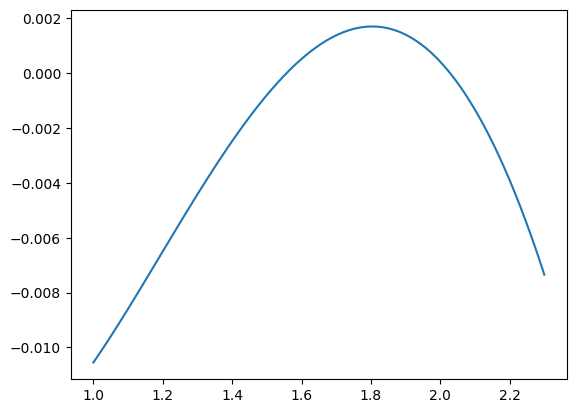

In [170]:
plt.plot(_l_input, _l_results)
# plt.hlines(0, 0.9, 2.2)
# plt.plot(_l_input, _l_results_alt)
# plt.ylim(-1, 1)

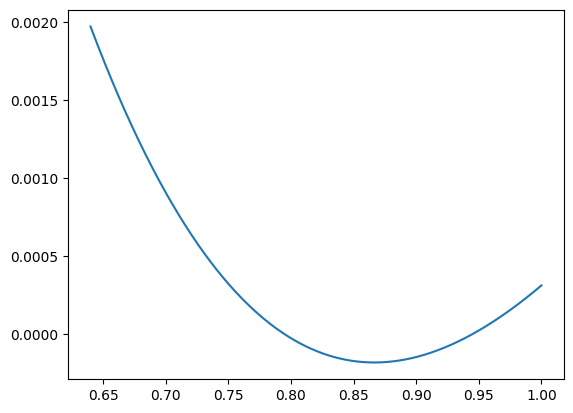

In [171]:
plt.plot(_m_input, _m_results)
# plt.ylim(0, 10)

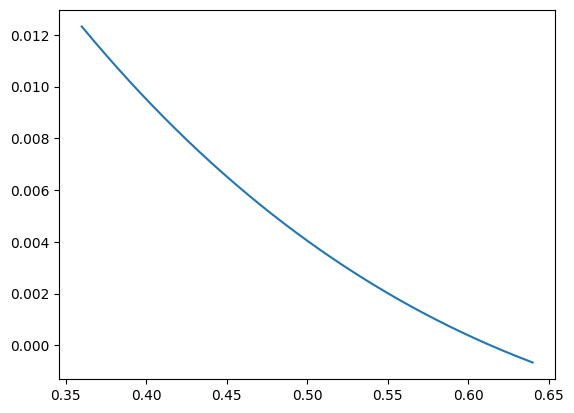

In [172]:
plt.plot(_n_input, _n_results)
# plt.ylim(-0.1, 0.0)

In [139]:
print(l_solve_here(aATS._l))
print(m_solve_here(aATS._m))
print(n_solve_here(aATS._n))

0.004832115672199322
-0.0010357456876987081
0.00773335094445643
